In [1]:
import sys
import os
from pathlib import Path

notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent
print(ROOT)
RAFT_PATH = ROOT / "external" / "RAFT-Stereo"
os.chdir(ROOT)
if str(RAFT_PATH) not in sys.path:
    sys.path.append(str(ROOT))

/srv/homes/onbo10/thesis_main


In [2]:
from utilities.visualizer_triangulation import TriangulationVisualizer
from src.Geometry.triangulation.triangulator import Triangulator
from src.Segmentation.data_postprocessing.masks_postprocessing import * 
import cv2
from src.Geometry.triangulation.triangulation_utils import *
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import pandas as pd
from src.Stereo_matching.stereo_matching_utils import *
from src.Stereo_matching.inference.S2M2_inferencer import S2M2Inferencer
from src.Stereo_matching.evaluation.compare_masks_disparities import disparity_vs_segmentation
from src.Stereo_matching.postprocessing.outliers_3D_filtering import *

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# Select examples selection and display variables
num_examples= 10
seed=10
fig_name= 'disparity_examples_2.png'
idx= 5


In [4]:
data_dir='data/SurgPose/SurgPose_for_HRNet/Extracted_right_test/extracted_frames'
results_dir= "results/Stereo_matching/Surgpose_test_disparity_maps/s2m2"
save_path= results_dir +  '/plots/'+ fig_name

In [5]:
selected_files= select_random_files(data_dir, num_examples, seed, file_path_structure="**/*.jpg")
left_img_root = 'data/SurgPose/SurgPose_for_HRNet/Extracted/extracted_frames'
zip_root= 'data/SurgPose/SurgPose_for_HRNet'

### S²M² results

* #### Examples and plots

In [6]:
cfg_path='configs/S2M2/s2m2_surgpose_test_set.yaml'


In [7]:
with open(cfg_path, 'r') as f:
        config_data = yaml.safe_load(f)
raft_inferencer = S2M2Inferencer(config_data['pretrained_folder'], model_type=config_data['model_type'],num_refine= config_data['num_refine'], allow_negative= config_data['allow_negative'],device='cuda')
img_shape= (config_data['h'],config_data['w']);

/srv/homes/onbo10/.conda/envs/s2m2/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Model loaded


In [8]:
s2m2_disparities= compute_disparities(raft_inferencer, right_img_paths=selected_files, left_img_root=left_img_root, zip_root=zip_root, img_shape=img_shape)

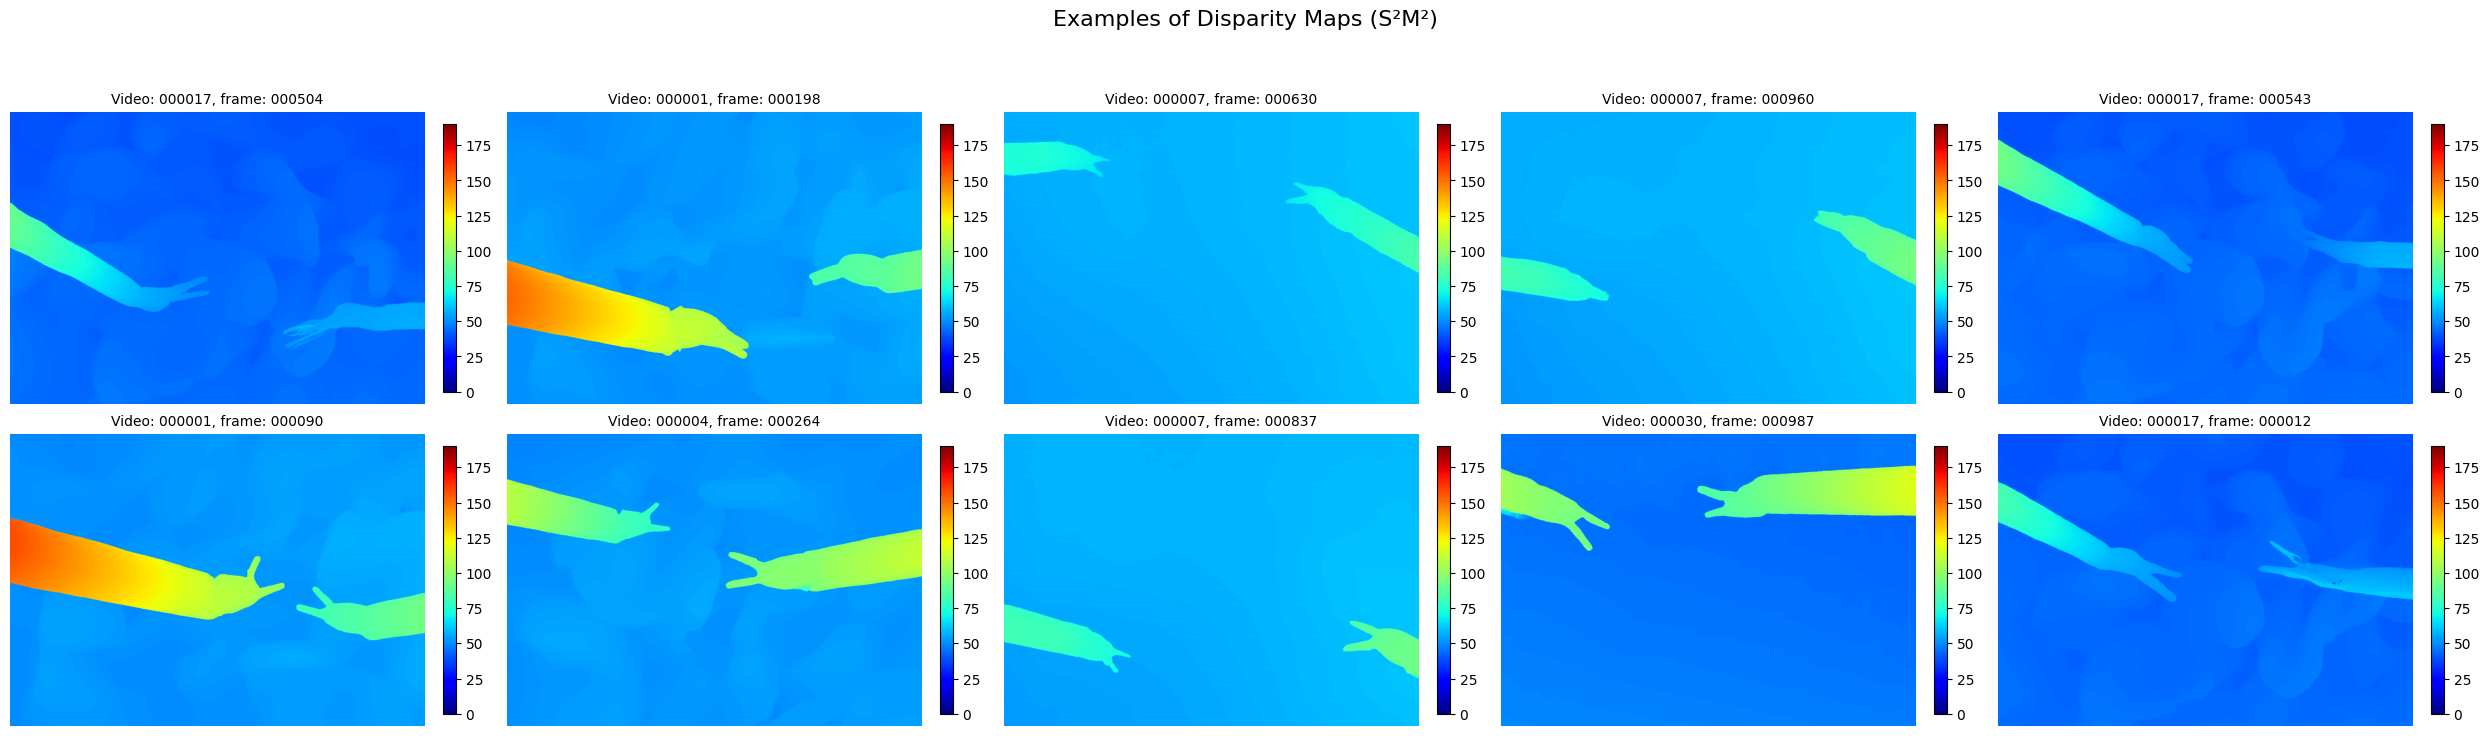

In [9]:
plot_selected_files(selected_files, s2m2_disparities, title= 'Examples of Disparity Maps (S²M²)',save_path=save_path, save= True)

In [6]:
selected_example_path= selected_files[idx]

In [7]:
left_mask_path, right_mask_path, zip_calib_path, left_img_path, right_img_path, frame_id=get_file_paths_from_compressed_file_path(selected_example_path,vid_id_position=0)

In [8]:
triangulator = Triangulator()
triangulator.load_calibration(zip_calib_path);

In [9]:
# load data
mask_l = cv2.imread(left_mask_path, cv2.IMREAD_GRAYSCALE)
mask_r = cv2.imread(right_mask_path, cv2.IMREAD_GRAYSCALE)
img_l = cv2.imread(left_img_path)
img_r= cv2.imread(right_img_path)
h, w = img_l.shape[:2]


In [59]:
# rectify
mode = "conventional"
lmap1, lmap2, rmap1, rmap2, q= triangulator.get_rectification_maps(img_size=(h,w), mode=mode)
rect_l, rect_r = triangulator.rectify_images(img_l, img_r,lmap1, lmap2, rmap1, rmap2, mode)
rect_mask_l = cv2.remap(mask_l, lmap1, lmap2, cv2.INTER_NEAREST)
rect_mask_r = cv2.remap(mask_r, rmap1, rmap2, cv2.INTER_NEAREST)


In [60]:
# get left disparity 
disp_l =  s2m2_disparities[idx]


In [61]:
points_3d_cloud, colors, disparity = triangulator.project_disparity_to_3d(disp_l, q, rect_l, rect_mask_l)

In [17]:
# Plot 3D reconstruction
visualizer = TriangulationVisualizer()

In [18]:

visualizer.plot_3d_plotly(points_3d=points_3d_cloud, colors=colors, frame_name=frame_id+', S²M² original')

#### Identifying a Problem with the segmentation masks

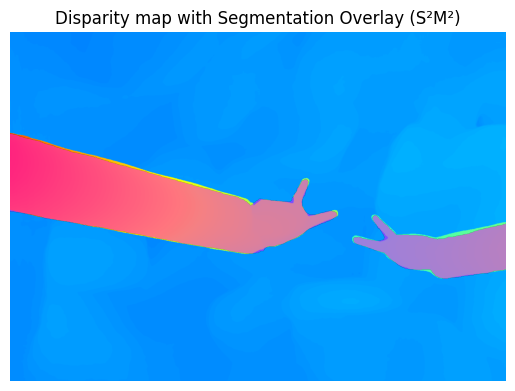

In [62]:

plt.imshow(disp_l, cmap='jet', vmin=0, vmax=190)
masked_data = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
plt.imshow(masked_data, cmap='spring', alpha=0.5)
plt.title('Disparity map with Segmentation Overlay (S²M²)')
plt.axis('off') 
plt.show()

In [20]:
#Erode segmentation mask
eroded_mask= erode_mask(rect_mask_l, iterations=3)

In [21]:
points_3d_cloud_eroded, colors, disparity = triangulator.project_disparity_to_3d(disp_l, q, rect_l, eroded_mask)

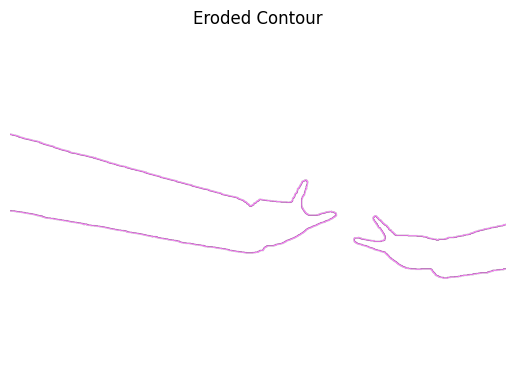

In [22]:

masked_data = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
plt.imshow(masked_data, cmap='spring', alpha=0.5)
masked_data_eroded = np.ma.masked_where(eroded_mask == 0, eroded_mask)
plt.imshow(masked_data_eroded, cmap='binary', alpha=1)
plt.title('Eroded Contour')
plt.axis('off') 
plt.show()

In [23]:
# Plot 3D reconstruction
visualizer = TriangulationVisualizer()

In [25]:

visualizer.plot_3d_plotly(points_3d=points_3d_cloud_eroded, colors=colors, frame_name=frame_id+', S²M² with eroded segmentation mask')

+ #### Evaluation stats

In [26]:
import pandas as pd
lrc_stats='results/Stereo_matching/Surgpose_test_disparity_maps/s2m2/lrc_stats_20260430_090857.csv'
df= pd.read_csv(lrc_stats)

In [27]:
df.head(10)

,video_id,frame,lrc_mean,lrc_std,lrc_max,lrc_min,consistency_rate,ssim_score,lrc_median
0,4,vid_000004_left_frame_000000,1.4072,5.5327,73.4304,0.0,73.71,0.6348,0.6970
1,4,vid_000004_left_frame_000003,1.3345,5.4590,76.0313,0.0,77.10,0.6007,0.6087
2,4,vid_000004_left_frame_000006,1.3608,5.6145,79.6180,0.0,74.60,0.6042,0.6014
3,4,vid_000004_left_frame_000009,1.3358,5.6690,82.3715,0.0,79.16,0.6032,0.5591
4,4,vid_000004_left_frame_000012,1.3569,5.8875,80.9876,0.0,79.31,0.5860,0.5355
5,4,vid_000004_left_frame_000015,1.3108,5.6982,80.0965,0.0,78.95,0.6018,0.5286
6,4,vid_000004_left_frame_000018,1.3322,5.7233,76.4720,0.0,78.61,0.6024,0.5695
7,4,vid_000004_left_frame_000021,1.3321,5.6724,77.5773,0.0,80.52,0.6021,0.5801
8,4,vid_000004_left_frame_000024,1.3632,5.8468,78.4007,0.0,80.44,0.5851,0.5683
9,4,vid_000004_left_frame_000027,1.3368,5.8203,78.2079,0.0,79.84,0.6007,0.5266


In [28]:
df.mean(numeric_only=True).drop('video_id')

lrc_mean             1.232458
lrc_std              4.606929
lrc_max             63.408672
lrc_min              0.000000
consistency_rate    75.373748
ssim_score           0.535756
lrc_median           0.596290
dtype: float64

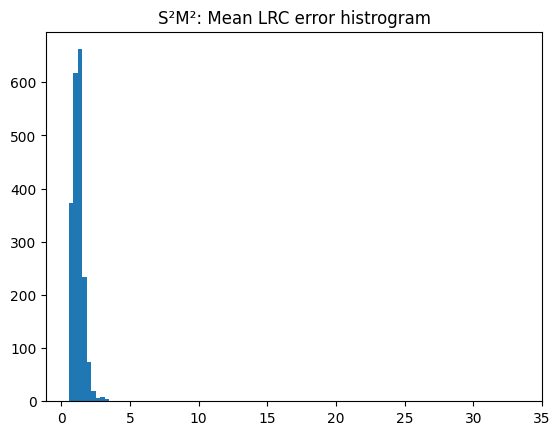

In [29]:
plt.hist(df['lrc_mean'], bins=100)
plt.title('S²M²: Mean LRC error histrogram')
plt.show()

#### Segmentation Mask quality exaluation

In [30]:
mask_csv_path='results/Stereo_matching/Surgpose_test_disparity_maps/s2m2/s2m2_disparity_segmentation_masks_eval_postprocessing_both_masks.csv'
mask_df=pd.read_csv(mask_csv_path)

In [31]:
mask_df.mean(numeric_only=True)

Disparity threshold    54.165087
Hausdorff distance     20.211870
Dice score              0.966321
dtype: float64

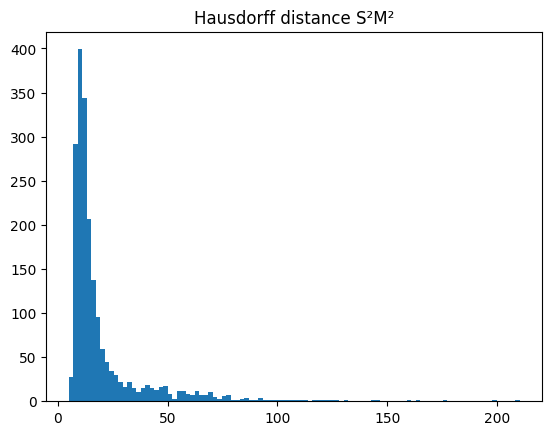

In [32]:
plt.hist(mask_df['Hausdorff distance'],bins=100)
plt.title('Hausdorff distance S²M²')
plt.show()

In [33]:
max_idx = mask_df['Hausdorff distance'].idxmax()
max_row = mask_df.loc[max_idx]

In [34]:
max_row

Frame                  vid_000033_frame_000237
Disparity threshold                    53.0106
Hausdorff distance                    210.1095
Dice score                              0.7473
Name: 1749, dtype: object

In [35]:
file_worst=Path('results/Stereo_matching/Surgpose_test_disparity_maps/s2m2/000033/compressed_data/vid_000033_frame_000237.npz')
disp_worst=np.load(file_worst)['disparity']


In [36]:

# Create a disparity mask using thresholding

disp_thres, disp_mask,rect_mask_l, frame_id, hd, dice = disparity_vs_segmentation(mask_postprocess=True, rect_mode='conventional', h=img_shape[0],w=img_shape[1],disp_file= file_worst,disp=disp_worst)

In [37]:
hd

210.10949526377908

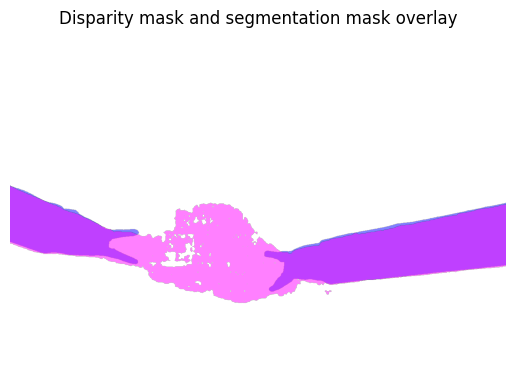

In [38]:

masked_data_disp = np.ma.masked_where(disp_mask == 0, disp_mask)
plt.imshow(masked_data_disp, cmap='winter', alpha=0.5)
masked_data = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
plt.imshow(masked_data, cmap='spring', alpha=0.5)
plt.title('Disparity mask and segmentation mask overlay')
plt.axis('off') 
plt.show()

In [39]:
def get_outlier_frames(df, threshold=100, num_samples=10):
    """
    Counts outliers and returns a list of frame names for random samples.
    """
    # 1. Filter for rows higher than threshold
    outliers = df[df['Hausdorff distance'] > threshold]
    
    # 2. Get the count
    total_outliers = len(outliers)
    print(f"Count of frames with Hausdorff > {threshold}: {total_outliers}")
    
    # 3. Sample and extract 'Frame' names
    # min() prevents errors if you have fewer than 10 outliers
    sample_count = min(num_samples, total_outliers)
    
    if sample_count > 0:
        sample_frames = outliers.sample(n=sample_count)['Frame'].tolist()
        return sample_frames
    else:
        return []

# Usage:
problematic_frames = get_outlier_frames(mask_df)
print(f"Sampled Frames: {problematic_frames}")

Count of frames with Hausdorff > 100: 26
Sampled Frames: ['vid_000030_frame_000807', 'vid_000017_frame_000357', 'vid_000017_frame_000984', 'vid_000017_frame_000513', 'vid_000017_frame_000099', 'vid_000017_frame_000246', 'vid_000017_frame_000966', 'vid_000033_frame_000315', 'vid_000017_frame_000978', 'vid_000017_frame_000975']


In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

def visualize_outlier_overlays(frame_list, base_dir='results/Stereo_matching/Surgpose_test_disparity_maps/s2m2'):
    """
    Constructs paths from frame names, runs metrics, and plots overlays in a grid with a global legend.
    """
    num_frames = len(frame_list)
    if num_frames == 0:
        print("No frames provided for visualization.")
        return


    cols = 5
    rows = (num_frames + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    

    if num_frames == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, frame_name in enumerate(frame_list):
      
        video_id = frame_name.split('_')[1]
        
  
        file_path = Path(base_dir) / video_id / 'compressed_data' / f"{frame_name}.npz"
        
        if not file_path.exists():
            print(f"Warning: File not found {file_path}")
            continue

        # 3. Load data
        data = np.load(file_path)
        disp_data = data['disparity']

     
        disp_thres, disp_mask, rect_mask_l, frame_id, hd, dice = disparity_vs_segmentation(
            mask_postprocess=True, 
            rect_mode='conventional', 
            h=disp_data.shape[0], 
            w=disp_data.shape[1], 
            disp_file=file_path, 
            disp=disp_data
        )

        
        ax = axes[i]
        
     
        masked_disp = np.ma.masked_where(disp_mask == 0, disp_mask)
        ax.imshow(masked_disp, cmap='winter', alpha=0.5)
        
       
        masked_seg = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
        ax.imshow(masked_seg, cmap='spring', alpha=0.5)
        
        ax.set_title(f"HD: {hd:.1f} | Dice: {dice:.2f}\n{frame_name}", fontsize=9)
        ax.axis('off')

    # 6. Create Legend Handles
    # Cyan roughly represents 'winter' and HotPink represents 'spring'
    disp_patch = mpatches.Patch(color='#8181f7', label='Disparity Mask ')
    seg_patch = mpatches.Patch(color='#d158f7', label='Segmentation Mask ')

    # Add a global legend to the bottom of the figure
    fig.legend(handles=[disp_patch, seg_patch], 
               loc='lower center', 
               ncol=2, 
               fontsize=12,
               bbox_to_anchor=(0.5, 0.02))

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.05, 1, 1]) 
    plt.show()

Count of frames with Hausdorff > 100: 26


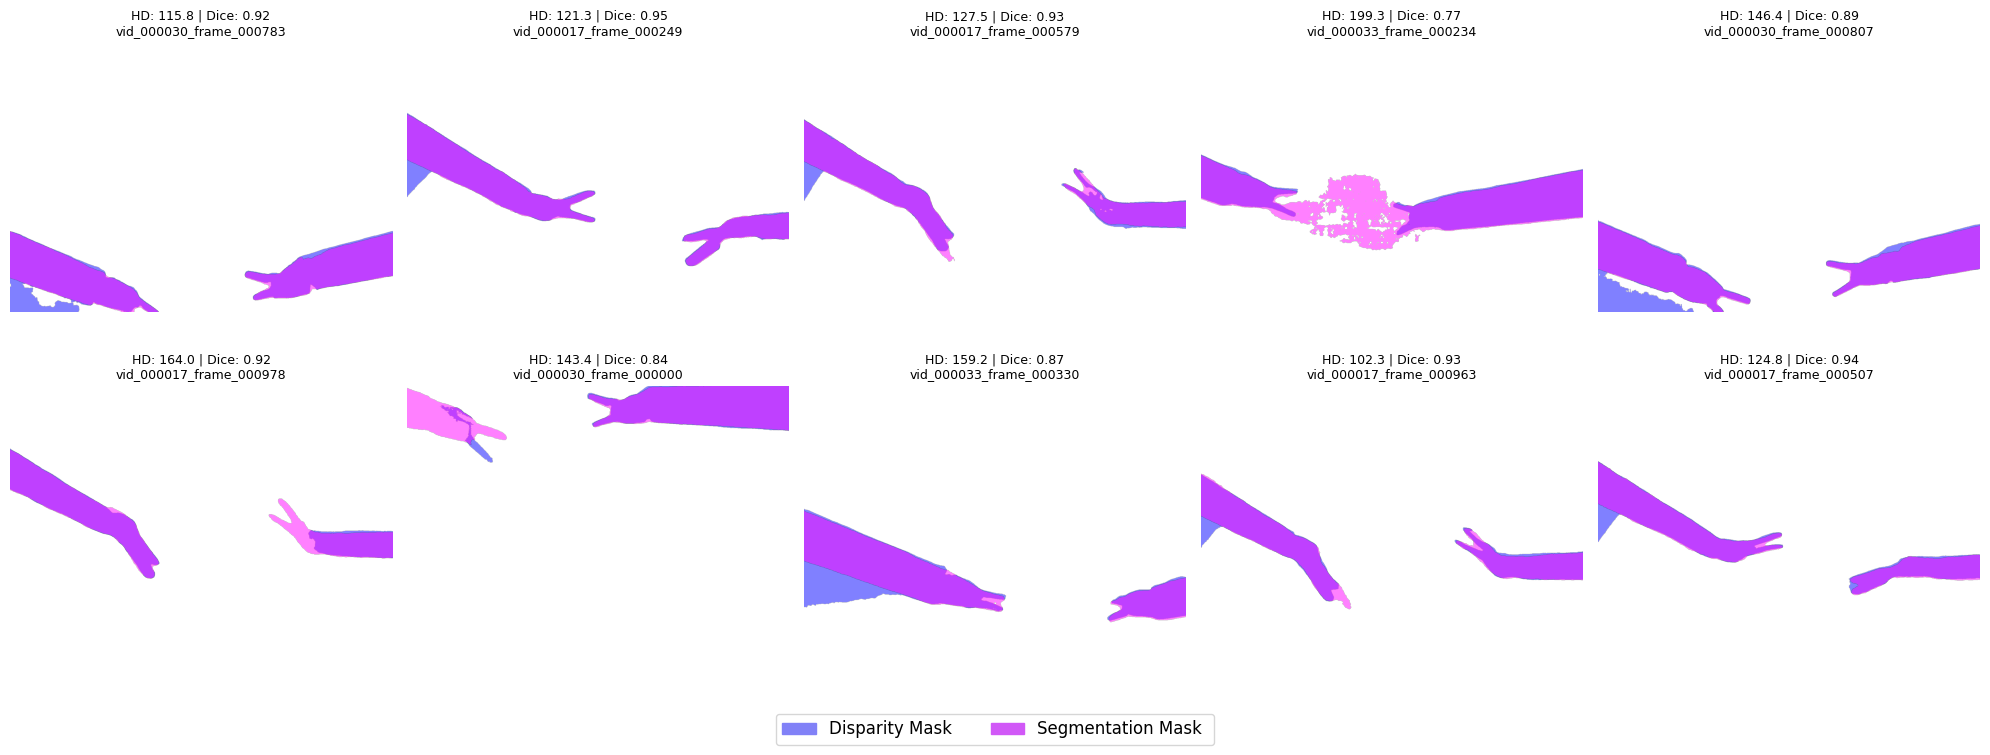

In [48]:

problematic_frames = get_outlier_frames(mask_df, threshold=100) 
visualize_outlier_overlays(problematic_frames,base_dir='results/Stereo_matching/Surgpose_test_disparity_maps/s2m2')

#### Outlier filtering


In [ ]:
#Using Z threshold
percentile=99
filtering_mask=adaptive_z_filtering(points_3d_cloud_eroded, percentile=percentile)

In [50]:
visualizer.plot_3d_plotly(points_3d=points_3d_cloud_eroded[filtering_mask], colors=colors[filtering_mask], frame_name=frame_id + f', S²M² with z-filtering (percentile={percentile}) ')

In [ ]:
#Using clustering 
filtering_mask=DBSCAN_cluster_filtering(points_3d_cloud_eroded, eps=5, min_points=20, top_n=2)

In [52]:
visualizer.plot_3d_plotly(points_3d=points_3d_cloud_eroded[filtering_mask], colors=colors[filtering_mask], frame_name=frame_id + f', S²M² with clusters filtering')